# Домашнее задание к занятию «Feature Select»

Выполнил: Ярослав Золотухин

## Генерация данных и рассчет средней точности логистической регрессии

In [20]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
x_data_generated, y_data_generated = make_classification(scale=1)
acc = cross_val_score(LogisticRegression(), x_data_generated, y_data_generated, scoring='accuracy').mean()
print(acc)

0.9399999999999998


## Статистические методы для отбора признаков

Выбираем признаки на основе матрицы корреляции.

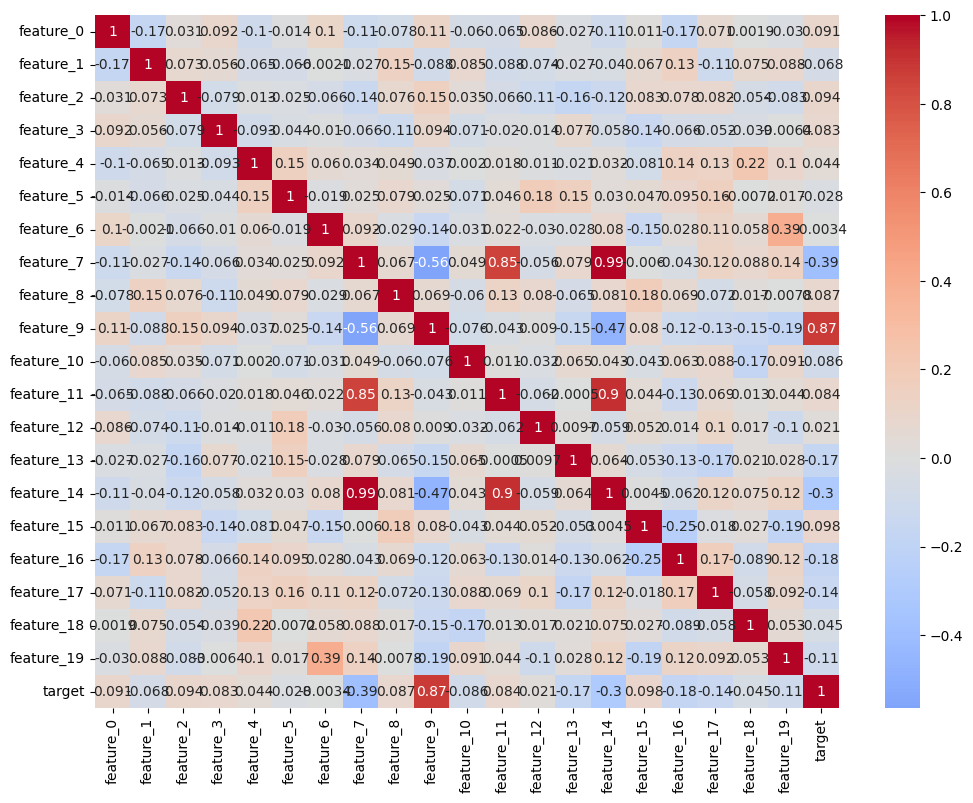

In [21]:
df_features = pd.DataFrame(x_data_generated, columns=[f'feature_{i}' for i in range(x_data_generated.shape[1])])
df_generated = df_features.copy()
df_generated['target'] = y_data_generated

corr = df_generated.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

In [39]:
from sklearn.metrics import mutual_info_score

for col in df_generated[:-1]:
    print('target -', col, mutual_info_score(df_generated[col], df_generated['target']))

target - feature_0 0.6929471672244787
target - feature_1 0.6929471672244787
target - feature_2 0.6929471672244787
target - feature_3 0.6929471672244787
target - feature_4 0.6929471672244787
target - feature_5 0.6929471672244787
target - feature_6 0.6929471672244788
target - feature_7 0.6929471672244787
target - feature_8 0.6929471672244787
target - feature_9 0.6929471672244788
target - feature_10 0.6929471672244787
target - feature_11 0.6929471672244787
target - feature_12 0.6929471672244787
target - feature_13 0.6929471672244787
target - feature_14 0.6929471672244787
target - feature_15 0.6929471672244787
target - feature_16 0.6929471672244787
target - feature_17 0.6929471672244787
target - feature_18 0.6929471672244787
target - feature_19 0.6929471672244787
target - target 0.6929471672244787


/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for t

Признаки показали идентичный mutual_info_score. Связано это с тем, что данные сгенерированы, при генерации дополнительный шум не был задан.

### Удалим признаки, которые имеют низкую вариантивность. Значение порога возьмем 80%

In [22]:
df_features.var().sort_values()

feature_7     0.077877
feature_12    0.665717
feature_3     0.801509
feature_15    0.867481
feature_14    0.874215
feature_10    0.879455
feature_2     0.916515
feature_17    0.932653
feature_1     0.971808
feature_0     1.006687
feature_18    1.050150
feature_19    1.105302
feature_6     1.134907
feature_5     1.211014
feature_8     1.224952
feature_4     1.228535
feature_16    1.242697
feature_13    1.329321
feature_9     1.487039
feature_11    1.789707
dtype: float64

In [23]:
from sklearn.feature_selection import VarianceThreshold


sel = VarianceThreshold(threshold=0.5)
x_data_selected = sel.fit_transform(df_features)
x_data_selected.shape

(100, 19)

Был исключен один признак. Рассчитаем точность логистической модели после преобразований.

In [24]:
acc_2 = cross_val_score(LogisticRegression(), x_data_selected, y_data_generated, scoring='accuracy').mean()
print(acc_2)

0.9399999999999998


Точность после преобразований не изменилась.

## Отбор признаков на основе дисперсионного анализа

In [38]:
from sklearn.feature_selection import SelectKBest
X_new = SelectKBest(k=5).fit_transform(x_data_generated, y_data_generated)
acc_3 = cross_val_score(LogisticRegression(), X_new, y_data_generated, scoring='accuracy').mean()
print(X_new.shape)
print(acc_3)

(100, 5)
0.97


Точность улучшена

## Отбор с использованием моделей

In [37]:
from sklearn.feature_selection import SelectFromModel

logReg = LogisticRegression(random_state=1, penalty='l1', solver='saga').fit(x_data_generated, y_data_generated)
selector = SelectFromModel(logReg, prefit=False, max_features=5, threshold=-np.inf)
X_tr = selector.fit_transform(x_data_generated, y_data_generated)
acc_4 = cross_val_score(LogisticRegression(), X_tr, y_data_generated, scoring='accuracy').mean()
print(X_tr.shape)
print(acc_4)

(100, 5)
0.97


/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Точность аналогична после отбора на основе дисперсионного анализа

In [36]:
from sklearn.ensemble import RandomForestClassifier


model_rf = RandomForestClassifier(random_state=1)
model_rf.fit(x_data_generated, y_data_generated) # обучение

importances = model_rf.feature_importances_

# выберем 5 самых важных признаков
top_features = np.argsort(importances)[-5:]

x_data_rf_selected = x_data_generated[:, top_features]

acc_5 = cross_val_score(LogisticRegression(), x_data_rf_selected, y_data_generated, scoring='accuracy').mean()
print(x_data_rf_selected.shape)
print(acc_5)


(100, 5)
0.97


Точность на уровне предыдущих отборов.

## Перебор признаков

In [34]:
from sklearn.feature_selection import SequentialFeatureSelector


sfs_backward = SequentialFeatureSelector(
    LogisticRegression(random_state=1), direction="backward"
)
sfs_backward.fit(x_data_generated, y_data_generated)
X_tr_seq = sfs_backward.transform(x_data_generated)
acc_6 = cross_val_score(LogisticRegression(), X_tr_seq, y_data_generated, scoring='accuracy').mean()
print(X_tr_seq.shape)
print(acc_6)

(100, 10)
0.96


# Вывод

В ходе данного домашнего задания каждый из подходов отборов признаков показал улучшение точности модели

| Способ выбора признаков | Количество признаков | Средняя точность модели |
|--------|----------------------|-------------------|
| Матрица корреляции | 20 | 94% |
| VarianceThreshold | 19 | 94% |
| SelectKBest(f_classif, k=5) | 5 | 97% |
| SelectFromModel + L1-регуляризация | 5 | 97% |
| RandomForest и встроенный атрибут feature_impotance | 5 | 97% |
| SequentialFeatureSelector | 10 | 96% |

В данном случае уменьшение количества признаков дало улучшение качества моделей.